# dac_capture test
Just trying to get the dac_player + dac_capture working

## Full Block Diagram
![full block diagram](bd_full.png)

## DAC Player
![dac_player_diagram](bd_dac_player.png)

## DAC Capture
(Note the modified structure with the "diag_readback_0" AXI peripheral which just makes its inputs readable via AXI)
![dac_capture_diagram](bd_dac_capture.png)

In [1]:
from pynq import Overlay, MMIO
import xrfclk

In [1]:
import dac_capture
import importlib
importlib.reload(dac_capture)

<module 'dac_capture' from '/home/xilinx/jupyter_notebooks/RFSoC-MTS/dac_capture/dac_capture.py'>

In [2]:
def print_attrs(obj, all=False):
    print("Attrs:")
    for attr in dir(obj):
        if all or (not attr.startswith("_")):
            print("  " + attr)

def print_dict(dd, indent=0, depth=-1):
    ind = " "*indent
    for key, val in dd.items():
        print("{}{}:".format(ind, key), end="")
        if hasattr(val, "keys"):
            if depth == 0:
                print(" dict len {}".format(len(val)))
            else:
                print()
                print_dict(val, indent+2, depth-1)
        else:
            print(" {}".format(val))

def print_dicts(obj, depth=-1):
    for dd, name in ((obj.ip_dict, "ip_dict"), (obj.mem_dict, "mem_dict"), (obj.hierarchy_dict, "hierarchy_dict")):
        print(name + ":")
        print_dict(dd, indent=2, depth=depth)

In [3]:
from pynq import MMIO
class DiagReadback():
    def __init__(self, baseAddr, num_regs=19):
        self._base = baseAddr
        mmios = [MMIO(baseAddr + 4*n) for n in range(num_regs)]
        # ========================= Memory Map =================================
        self._mmios_first_tdata = mmios[:8]
        self._mmios_last_tdata = mmios[8:16]
        self._mmios_trigger_counter = mmios[16:17]
        self._mmios_rollover_counter = mmios[17:18]
        self._mmios_tvalid_counter = mmios[18:19]

    def get_first_tdata_list(self):
        return [mmio.read() for mmio in self._mmios_first_tdata]

    def get_last_tdata_list(self):
        return [mmio.read() for mmio in self._mmios_last_tdata]

    def get_trigger_counter(self):
        return self._mmios_trigger_counter[0].read() & 0xff

    def get_rollover_counter(self):
        return self._mmios_rollover_counter[0].read() & 0xff

    def get_tvalid_counter(self):
        return self._mmios_tvalid_counter[0].read() & 0xff

In [4]:
ol = dac_capture.dcOverlay("dac_capture.bit")
ol.is_loaded()

True

In [5]:
rbk = DiagReadback(0xA0000000)

In [13]:
print(rbk.get_trigger_counter())
print(rbk.get_rollover_counter())
print(rbk.get_tvalid_counter())

1
1
1


In [7]:
print(rbk.get_first_tdata_list())
print(rbk.get_last_tdata_list())

[0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp
from scipy.signal import sawtooth
from scipy.signal import gausspulse

DAC_SR = dac_capture.ZCU208_LMX_FREQ * 1.0e6  # Sample rate of DACs and ADCs is 4.0 GHz
ADC_SR = dac_capture.ZCU208_LMX_FREQ * 1.0e6
Fc = 250.0E6 # Set center frequency of waveform to 250.0 MHz
Fe = 800.0E6 # maximum frequency of chirp at end of record
DAC_Amplitude = 16383.0 # 14bit DAC +16383/-16384
# DAC_Amplitude = 100.0 # 14bit DAC +16383/-16384
n_samples = ol.dac_player.size
X_axis = (1/DAC_SR) * np.arange(n_samples)

In [9]:
# generate some basic waveforms
DAC_sinewave = DAC_Amplitude * np.sin(2*np.pi*Fc*X_axis)
DAC_sawtooth = DAC_Amplitude * sawtooth(2 * np.pi * Fc * X_axis)
DAC_chirp = DAC_Amplitude * chirp(np.arange(0, ol.dac_player.shape[0])/DAC_SR,
                                  f0=Fc, f1=Fe, t1=(ol.dac_player.shape[0]/DAC_SR), 
                                  phi=0.0, method='linear')
DAC_const = DAC_Amplitude * np.ones((1,len(ol.dac_player)), dtype=np.int16)

In [14]:
ol.dac_player[:] = np.int16(DAC_sinewave)
# ol.dac_player[:] = np.int16(DAC_sawtooth)
# ol.dac_player[:] = np.int16(DAC_chirp)
# ol.dac_player[:] = DAC_const

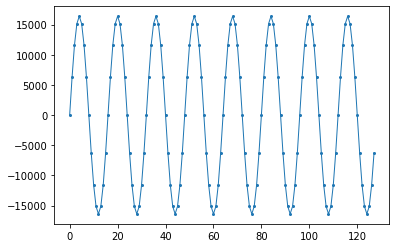

In [15]:
ol.trigger_capture()
plt.plot(ol.dac_capture[:128], marker='o', linewidth=1, markersize=2);

In [12]:
print(ol.dac_player[0])
print(ol.dac_player[-1])

16383
16383


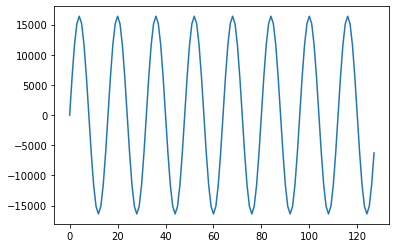

In [8]:
plt.plot(DAC_sinewave[:128])

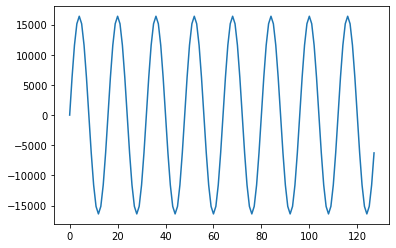

In [9]:
plt.plot(ol.dac_player[:128])

In [10]:
ol.verify_clock_tree()

In [7]:
print_attrs(ol.hier_dac_cap)

Attrs:
  axi_bram_ctrl_0
  bitstreams
  checkhierarchy
  description
  device
  download
  parsers
  pr_loaded


In [15]:
ol.hier_dac_cap.axi_bram_ctrl_0.mmio.read()

0

In [5]:
print_dicts(ol, depth=1)

ip_dict:
  clocktreeMTS/MTSclkwiz:
    type: xilinx.com:ip:clk_wiz:6.0
    mem_id: s_axi_lite
    memtype: REGISTER
    gpio: dict len 0
    interrupts: dict len 0
    parameters: dict len 606
    registers: dict len 0
    driver: <class 'pynq.overlay.DefaultIP'>
    device: <pynq.pl_server.embedded_device.EmbeddedDevice object at 0xffff944e5d20>
    state: None
    bdtype: None
    phys_addr: 2147811328
    addr_range: 65536
    fullpath: clocktreeMTS/MTSclkwiz
  gpio_control/axi_gpio_fifoflush:
    type: xilinx.com:ip:axi_gpio:2.0
    mem_id: S_AXI
    memtype: REGISTER
    gpio: dict len 0
    interrupts: dict len 0
    parameters: dict len 53
    registers: dict len 7
    driver: <class 'pynq.lib.axigpio.AxiGPIO'>
    device: <pynq.pl_server.embedded_device.EmbeddedDevice object at 0xffff944e5d20>
    state: None
    bdtype: None
    phys_addr: 2147876864
    addr_range: 65536
    fullpath: gpio_control/axi_gpio_fifoflush
  gpio_control/axi_gpio_spi_mux:
    type: xilinx.com:ip:axi

In [6]:
print_dict(ol.hierarchy_dict["hier_dac_cap"], depth=1)

ip:
memories:
  axi_bram_ctrl_0: dict len 20
hierarchies:
interrupts:
gpio:
fullpath: hier_dac_cap
device: <pynq.pl_server.embedded_device.EmbeddedDevice object at 0xffff944e5d20>
driver: <function DocumentHierarchy at 0xffff950db1c0>
overlay: <dac_capture.dcOverlay object at 0xffff944e7790>
